# Mini projet - Machine Learning/GenAI - SDV Rennes 2026

## Objectif
Durant ce mini projet, on va essayer de travailler avec des données réelles.
Il est temps d'appliquer vos compétences acquises pendant cet enseignement dans un mini projet de modélisation décisionnelle à partir des données.
L'objectif est de déterminer la qualité d'un vin à partir de mesures des composantes chimiques.


## Sujet proposé
La prédiction de la qualité (entier entre 0 et 10) du vin à partir des mesures de ses composantes chimiques.
Pour ce mini projet, je propose d'utiliser ce dataset : http://archive.ics.uci.edu/ml/datasets/Wine+Quality


## Références utiles
- [Documentation scikit-learn](http://scikit-learn.org/stable/index.html)
- [Documentation Pandas](https://pandas.pydata.org/docs)
- [Documentation NumPy](https://docs.scipy.org/doc/numpy/user/index.html)
- [Documentation Matplotlib](http://matplotlib.org/)
- [Documentation Seaborn](https://seaborn.pydata.org/)
- [Dataset wine quality](http://archive.ics.uci.edu/ml/datasets/Wine+Quality)


## Déroulement
### Evaluation pratique (20 points)
- Ce mini projet fera l'objet de l'évaluation pratique de l'examen.
- Pour qu'on soit efficace, et que ça soit un mini projet que vous pourriez utiliser comme référence, celui-ci sera guidé.
- Travail en binôme/trinôme fortement conseillé.



## Exercice 1 : Point métier
### Question 1.1 : Objectif
- C'est quoi l'objectif de cette modélisation décisionnelle ? Dans la vraie vie, à ce stade, un point s'impose avec le PO pour clarifier le besoin. Aujourd'hui, vous portez sa casquette 😃 à la discussion entre binôme 😏

L'objectif est de travailler les données des vins en fonction de leur type, ils seront classés par types (rouge ou blanc), le but est de faire des prédictions sur la qualité qu'ils auront. L'objectif est aussi de comparé les rouges et blancs pour savoir pour lequel on produit le meilleur vin



### Question 1.2 : Méthode décisionnelle
- Analytiquement, existe-t-il une méthode qui nous permet de construire un modèle décisionnel fiable qui répond à l'objectif de l'étude ? Donnez une réponse logique, si possible avec un lien de référence.

Oui la classification nous permettrait de voir quel vin on produira le mieux

Pour le reste du projet, on va adopter le choix d'appliquer une modélisation décisionnelle à partir des données.

## Exercice 2 : Chargement des données
### Question 2.1 : Création du dataset
Télécharger les 2 fichiers `winequality-red.csv` et `winequality-white.csv` depuis [ce lien](http://archive.ics.uci.edu/ml/datasets/Wine+Quality)
Former votre dataset à partir des 2 fichiers déjà téléchargés.
Afficher les 3 premières lignes du dataset.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_red = pd.read_csv('data/winequality-red.csv', sep=';')
df_white = pd.read_csv('data/winequality-white.csv', sep=';')

df_red['type'] = 'red'
df_white['type'] = 'white'

df = pd.concat([df_red, df_white], ignore_index=True)

df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red


### Question 2.2 : Confirmation du choix du dataset
- Existe-t-il une différence entre les vins rouges et vins blancs en terme de qualité ?
- Pour répondre à cette question, tracer une courbe qui groupe les données suivant le type du vin.
- Sur le même graphique, mettez l'accent sur la qualité.
- Commenter le graphique ?

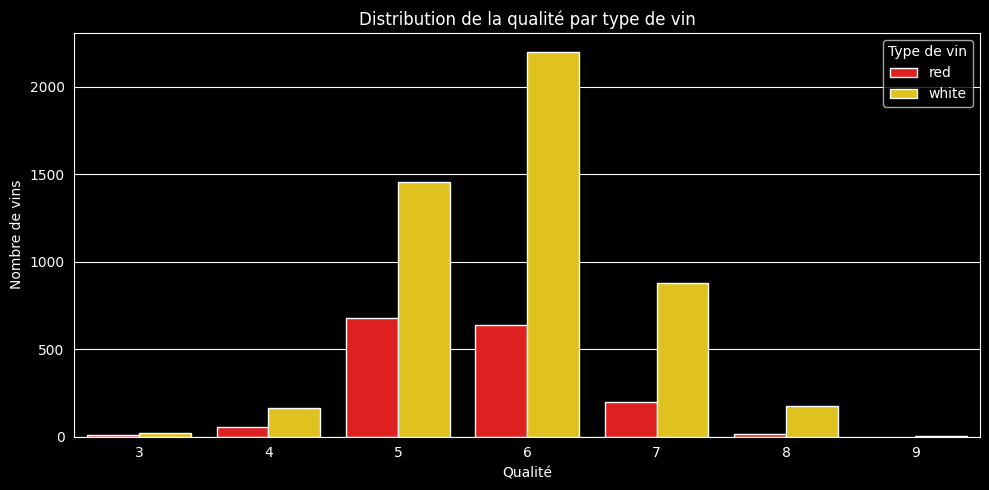

In [6]:
quality_counts = df.groupby(['type', 'quality']).size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.barplot(data=quality_counts, x='quality', y='count', hue='type', palette={'red': 'red', 'white': 'gold'})
plt.title('Distribution de la qualité par type de vin')
plt.xlabel('Qualité')
plt.ylabel('Nombre de vins')
plt.legend(title='Type de vin')
plt.tight_layout()
plt.show()

Ton interprétation ici

## Exercice 3 : Analyse exploratoire
**NB:** Pour le reste du projet, on va travailler avec le dataset formé par les vins rouges et blancs.


### Question 3.1 : Etat des lieux
- Afficher la description puis les informations du dataset
- Quel est le nombre d'observations qu'on a dans le dataset ?
- Combien de variables possède le dataset ?
>- Combien de variables continues ?
>- Combien de variables qualitatives ?

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [8]:
df.info()

print(f"\nNombre d'observations : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")
print(f"  - Variables continues : {df.select_dtypes(include='number').shape[1]}")
print(f"  - Variables qualitatives : {df.select_dtypes(include='object').shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB

Nombre d'observations : 6497
Nombre de variables : 13
  - Variables continues

/tmp/ipykernel_679619/322759664.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"  - Variables qualitatives : {df.select_dtypes(include='object').shape[1]}")


Ton interprétation ici

### Question 3.2 : Variables
- Quelles sont les variables explicatives ?
- Quelle est la variable expliquée ?

**Variables explicatives (features) :** toutes les colonnes sauf `quality` :

`fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`, `type`**Variable expliquée (cible) :** `quality` — la note de qualité du vin (entier entre 0 et 10).#TODO your code here

Ton interprétation ici

### Question 3.3 : Variables qualitatives
- Appliquez une transformation sur les variables qualitatives.

In [27]:
print(df.select_dtypes(include='str'))

df['type'] = df['type'].map({'red': 0, 'white': 1})

print(df['type'].value_counts())
df.head(3)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[6497 rows x 0 columns]
Series([], Name: count, dtype: int64)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,NaN
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,NaN
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,NaN


Ton interprétation ici

### Question 3.4 : Vérification des données manquantes
- Effectuez une vérification sur les données manquantes.
- Combien d'individus présentent des données manquantes ?

In [34]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
for col, count in missing_values.items():
    print(f"{col} : {count}")

type : 6497


Ton interprétation ici

### Question 3.5 : Imputation des données manquantes
- En dehors du contexte de ce projet, proposez une méthode pour imputer des données manquantes.
- Pour ce projet, quelle méthode proposez-vous pour imputer des données manquantes ?
- Que faîtes-vous dans le cas où on a des données manquantes dans la colonne de la variable expliquée ?

In [33]:
missing = df.isnull().sum()
print("Données manquantes par colonne :")
print(missing[missing > 0] if missing.any() else "Aucune donnée manquante.")

Données manquantes par colonne :
type    6497
dtype: int64


Aucune imputation nécessaire pour ce dataset.


Ton interprétation ici

### Question 3.6 : Analyse du nombre des observations par qualité
- Proposez un graphique afin de visualiser le nombre d'observations par qualité.
- Commentez ce graphique.

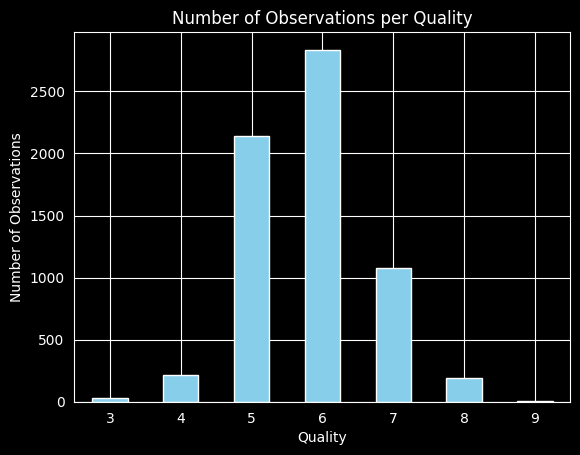

In [49]:
import matplotlib.pyplot as plt

counts = df['quality'].value_counts().sort_index()

counts.plot(kind='bar', color='skyblue')
plt.xlabel('Quality')
plt.ylabel('Number of Observations')
plt.title('Number of Observations per Quality')
plt.xticks(rotation=0)
plt.show()

Ton interprétation ici

### Question 3.7 : Analyse de la corrélation
- Proposer un graphique qui met en évidence la corrélation entre les différentes variables.
- Commenter ce graphique.

In [ ]:
#TODO your code here

In [ ]:
#TODO your code here

Ton interprétation ici

### Question 3.8 : Fractionnement en Features X et Target y
- Fractionnez votre dataset en deux parties : `X` pour les features et `y` pour la variable cible.

In [ ]:
#TODO your code here

### Question 3.9 : Split en subsets de Train et Test
- Formez les subsets d'entraînement (2/3) et de test (1/3)

In [ ]:
#TODO your code here

### Question 3.10 :  Distribution des 4 meilleurs variables explicatives
- Proposer sur la même figure 4 graphiques qui mettent en évidence la distribution des 4 meilleures variables sélectionnées par filtrage.
- Que remarquez-vous ? Peut-on mieux optimiser les données d'entrée ?

In [ ]:
#TODO your code here

Ton interprétation ici

**NB :** Pour le reste du projet, on va travailler avec les variables explicatives suivantes :
```
'fixed acidity',
'volatile acidity',
'citric acid',
'residual sugar',
'chlorides',
'free sulfur dioxide',
'total sulfur dioxide',
'density',
'pH',
'sulphates',
'alcohol'
```

## Exercice 4 : Modélisation
### Question 4.1 : Remise à l'échelle
- Décrivez les distributions des différentes variables explicatives.
- Est-il nécessaire de mettre à l'échelle les données du dataset ? Justifiez votre réponse. Si c'est le cas faites-le.


In [ ]:
#TODO your code here

In [ ]:
#TODO your code here

Ton interprétation ici

### Question 4.2 : Création du modèle
- Choisissez un modèle sklearn pour l'entrainer et créer le votre. [Documentation](https://scikit-learn.org/stable/supervised_learning.html)
- Exemples:
>- Pour une classification, vous pouvez utiliser l'un de ces modèles: [RidgeClassifier](https://scikit-learn.org/stable/modules/linear_model.html#classification), [SVC](https://scikit-learn.org/stable/modules/svm.html#classification), [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/tree.html#classification), [MLPClassifier](https://scikit-learn.org/stable/modules/neural_networks_supervised.html#classification), [RandomForestClassifier](https://scikit-learn.org/stable/modules/ensemble.html#classification), etc.
>- Pour une régression, vous pouvez utiliser l'un de ces modèles: [SVR](https://scikit-learn.org/stable/modules/svm.html#regression), [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/tree.html#regression), [MLPRegressor](https://scikit-learn.org/stable/modules/neural_networks_supervised.html#regression), [RandomForestRegressor](https://scikit-learn.org/stable/modules/ensemble.html#regression), etc.

In [ ]:
# TODO your code here

### Question 4.3 : Evaluation du modèle
- Calculez la précision du score sur le subset d'entrainement puis sur le subset de test

In [ ]:
# TODO your code here

### Question 4.4 : Optimisation du résultat
- Pourriez-vous proposer une méthode qui optimise plus encore la précision du modèle sélectionné ?
- Pourriez-vous proposer une méthode qui permet de déterminer le meilleur modèle parmi une liste définie de modèles ?

In [ ]:
# TODO your code here

In [ ]:
# TODO your code here

### Question 4.5 : Prédiction
Prédire la qualité du vin (rouge) dont les composants chimiques sont les suivantss:
`
'fixed acidity': 7,
'volatile acidity': 0.7,
'citric acid': 0,
'residual sugar': 2,
'chlorides': 0.1,
'free sulfur dioxide': 13,
'total sulfur dioxide': 40,
'density': 0.99,
'pH': 3.5,
'sulphates': 0.6,
'alcohol': 9.5
`

### Question 4.6 : Sauvegarde du modèle
- Exporter le modèle dans un format utilisable par une api externe.

## Exercice 5 : Utilisation externe du modèle
- Avec une techno de votre choix, proposez une interface web qui utilise le modèle déjà exporté dans la question 4.6 pour prédire la qualité du vin.

## Exercice 6 : Utilisation de l'IA Générative
- En utilisant une architecture RAG, proposer un chatbot spécialisé en vin pour confirmer/vérifier/enrichir les prédictions de votre modèle développé ci-dessus.
- Exemples de base de connaissances que vous pouvez utiliser:
    - [https://ioc.eu.com/wp-content/uploads/2023/11/IOC_LEAFLET_ZERO-ADD_WEB-3.pdf](https://ioc.eu.com/wp-content/uploads/2023/11/IOC_LEAFLET_ZERO-ADD_WEB-3.pdf)
    - [https://www.economie.gouv.fr/files/files/directions_services/dgccrf/documentation/publications/depliants/guide-liste-ingredients-nutritionnelle-des-vins.pdf](https://www.economie.gouv.fr/files/files/directions_services/dgccrf/documentation/publications/depliants/guide-liste-ingredients-nutritionnelle-des-vins.pdf)
    - Vous pouvez aussi utiliser d'autres documents que vous trouverez sur internet.


A vous de jouer ! 🚀 Bon courage 🍀

# Auteur
- [Mohamed ZWAWA](https://www.linkedin.com/in/mtzwawa)